# 🚗 Tesla Stock Price Prediction using SimpleRNN & LSTM
**Domain:** Financial Services  
**Target:** Predict 1-day, 5-day, and 10-day closing price of TSLA  
**Models:** SimpleRNN vs LSTM  
**Dataset:** TSLA.csv (Jun 2010 – Feb 2020, 2416 trading days)

---


## 1. Imports & Setup

In [1]:
import warnings, os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
COLORS = {'actual': '#1f77b4', 'rnn': '#e74c3c', 'lstm': '#2ecc71', 'bg': '#0d1117'}


print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Pandas version     : {pd.__version__}")


TensorFlow version : 2.21.0
NumPy version      : 2.1.0
Pandas version     : 2.3.1


## 2. Load & Inspect Dataset

In [2]:
df = pd.read_csv('TSLA.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

print("Shape:", df.shape)
print("\nDate range:", df['Date'].min().date(), "→", df['Date'].max().date())
print("\nColumn dtypes:")
print(df.dtypes)
df.head(10)


Shape: (2416, 7)

Date range: 2010-06-29 → 2020-02-03

Column dtypes:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.000000,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.420000,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.920000,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.100000,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.000000,15.830000,16.110001,16.110001,6866900
5,2010-07-07,16.400000,16.629999,14.980000,15.800000,15.800000,6921700
6,2010-07-08,16.139999,17.520000,15.570000,17.459999,17.459999,7711400
7,2010-07-09,17.580000,17.900000,16.549999,17.400000,17.400000,4050600
8,2010-07-12,17.950001,18.070000,17.000000,17.049999,17.049999,2202500
9,2010-07-13,17.389999,18.639999,16.900000,18.139999,18.139999,2680100


## 3. Exploratory Data Analysis (EDA)

In [3]:
print("=== Statistical Summary ===")
print(df.describe().round(2))


=== Statistical Summary ===
                                Date     Open     High      Low    Close  \
count                           2416  2416.00  2416.00  2416.00  2416.00   
mean   2015-04-15 11:09:56.026490112   186.27   189.58   182.92   186.40   
min              2010-06-29 00:00:00    16.14    16.63    14.98    15.80   
25%              2012-11-19 18:00:00    34.34    34.90    33.59    34.40   
50%              2015-04-16 12:00:00   213.04   216.75   208.87   212.96   
75%              2017-09-07 06:00:00   266.45   270.93   262.10   266.77   
max              2020-02-03 00:00:00   673.69   786.14   673.52   780.00   
std                              NaN   118.74   120.89   116.86   119.14   

       Adj Close       Volume  
count    2416.00      2416.00  
mean      186.40   5572721.69  
min        15.80    118500.00  
25%        34.40   1899275.00  
50%       212.96   4578400.00  
75%       266.77   7361150.00  
max       780.00  47065000.00  
std       119.14   4987809.15  

In [4]:
# Missing value check
print("=== Missing Values ===")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


=== Missing Values ===
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Duplicate rows: 0


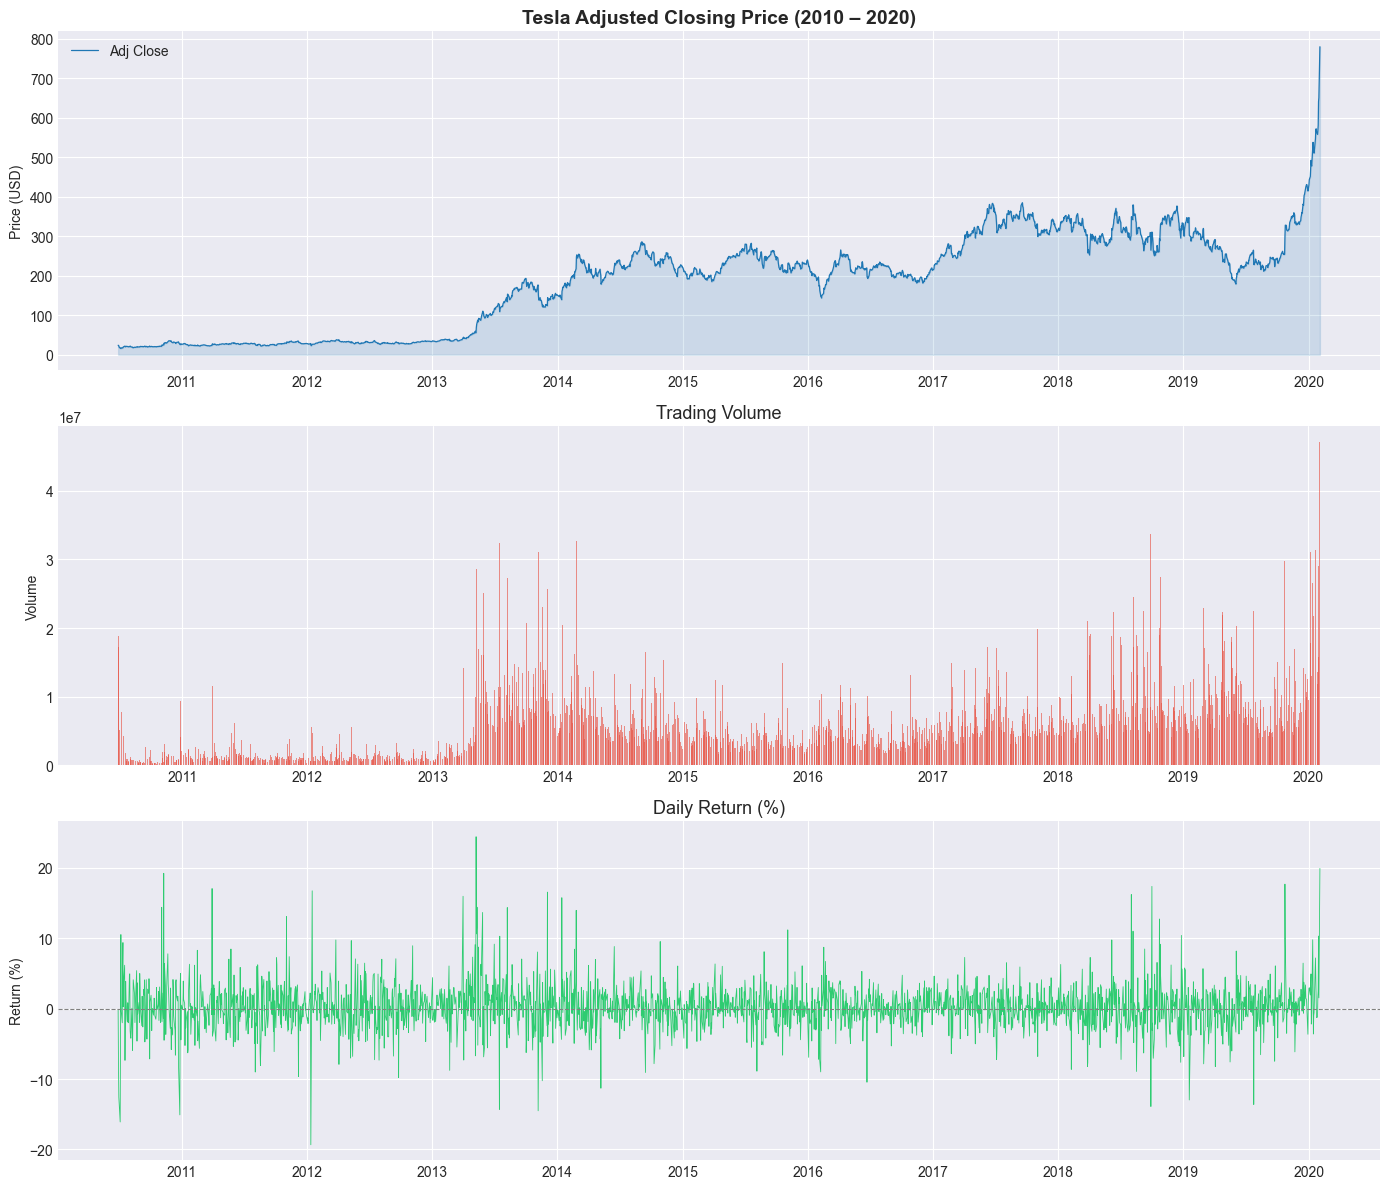

Saved: 01_price_history.png


In [5]:
# ── Full price history ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Closing price
axes[0].plot(df['Date'], df['Adj Close'], color='#1f77b4', linewidth=0.9, label='Adj Close')
axes[0].fill_between(df['Date'], df['Adj Close'], alpha=0.15, color='#1f77b4')
axes[0].set_title('Tesla Adjusted Closing Price (2010 – 2020)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# Volume
axes[1].bar(df['Date'], df['Volume'], color='#e74c3c', alpha=0.6, width=1.5)
axes[1].set_title('Trading Volume', fontsize=13)
axes[1].set_ylabel('Volume')

# Daily return
df['Daily_Return'] = df['Adj Close'].pct_change() * 100
axes[2].plot(df['Date'], df['Daily_Return'], color='#2ecc71', linewidth=0.6)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title('Daily Return (%)', fontsize=13)
axes[2].set_ylabel('Return (%)')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.savefig('01_price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_price_history.png")


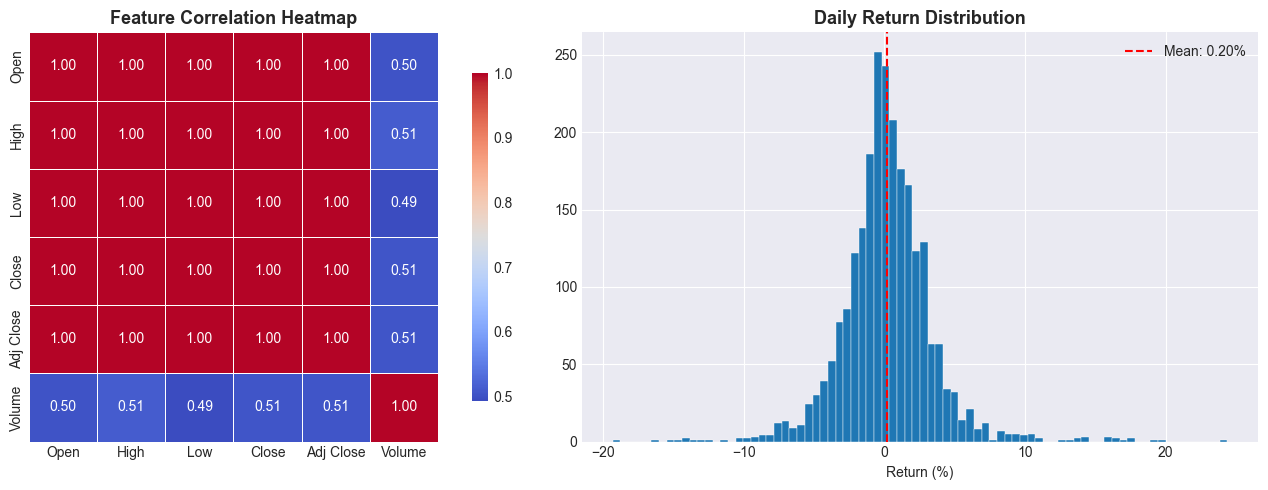

In [6]:
# ── Correlation heatmap + distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr = df[['Open','High','Low','Close','Adj Close','Volume']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0],
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')

axes[1].hist(df['Daily_Return'].dropna(), bins=80, color='#1f77b4',
             edgecolor='white', linewidth=0.3)
axes[1].axvline(df['Daily_Return'].mean(), color='red', linestyle='--', label=f"Mean: {df['Daily_Return'].mean():.2f}%")
axes[1].set_title('Daily Return Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Return (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('02_corr_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


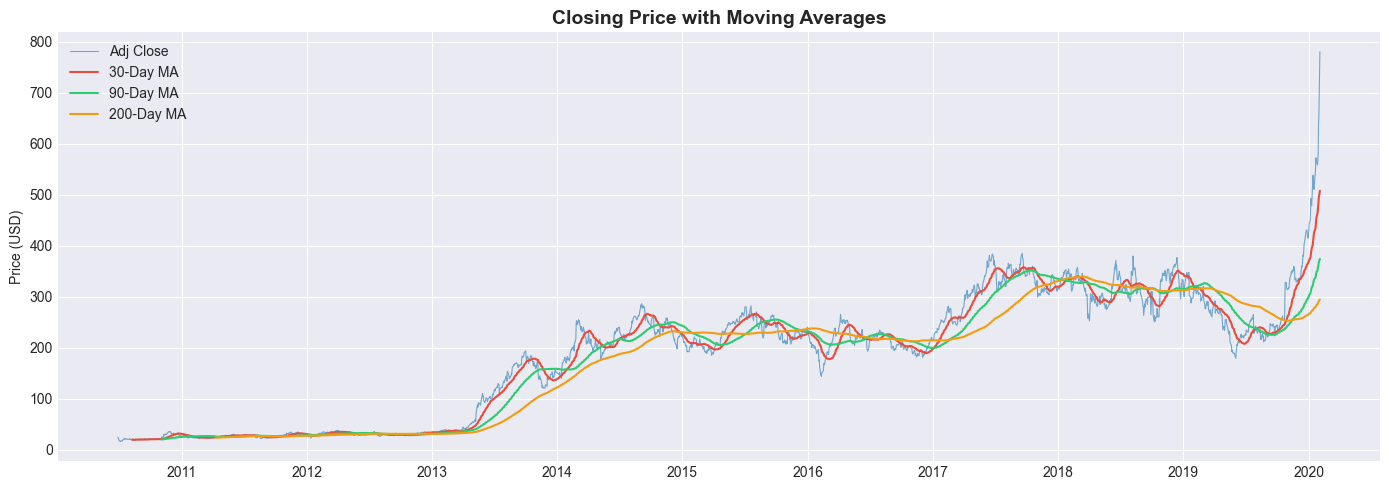

In [7]:
# ── Rolling statistics ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Date'], df['Adj Close'], label='Adj Close', alpha=0.6, linewidth=0.8, color='#1f77b4')
ax.plot(df['Date'], df['Adj Close'].rolling(30).mean(), label='30-Day MA', linewidth=1.5, color='#e74c3c')
ax.plot(df['Date'], df['Adj Close'].rolling(90).mean(), label='90-Day MA', linewidth=1.5, color='#2ecc71')
ax.plot(df['Date'], df['Adj Close'].rolling(200).mean(), label='200-Day MA', linewidth=1.5, color='#f39c12')
ax.set_title('Closing Price with Moving Averages', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('03_moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Data Preprocessing

### 4.1 Feature Selection & Missing Value Handling
We use **Adj Close** as the target. Since stock data is time-ordered, forward-fill is used if gaps exist (preserves temporal continuity without look-ahead bias).


In [8]:
# Drop helper column before preprocessing
df.drop(columns=['Daily_Return'], inplace=True)

# Use Adj Close as target
target_col = 'Adj Close'
data = df[['Date', target_col]].copy()

# Handle missing values (temporal data → forward fill, then backward fill for leading NaN)
data[target_col] = data[target_col].ffill()
data[target_col] = data[target_col].bfill()
print("Missing values after fill:", data[target_col].isnull().sum())
print("Total records:", len(data))


Missing values after fill: 0
Total records: 2416


### 4.2 Train / Test Split (80/20)

In [9]:
prices = data[target_col].values.reshape(-1, 1)

split_idx = int(len(prices) * 0.80)
train_raw = prices[:split_idx]
test_raw  = prices[split_idx:]

print(f"Train size : {len(train_raw):,}  ({split_idx})")
print(f"Test  size : {len(test_raw):,}  ({len(prices) - split_idx})")
print(f"Train ends : {data['Date'].iloc[split_idx-1].date()}")
print(f"Test starts: {data['Date'].iloc[split_idx].date()}")


Train size : 1,932  (1932)
Test  size : 484  (484)
Train ends : 2018-03-01
Test starts: 2018-03-02


### 4.3 Scaling (MinMaxScaler)

In [10]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)   # fit ONLY on train to prevent data leakage
test_scaled  = scaler.transform(test_raw)

print("Train scaled — min:", train_scaled.min().round(4), " max:", train_scaled.max().round(4))
print("Test  scaled — min:", test_scaled.min().round(4),  " max:", test_scaled.max().round(4))


Train scaled — min: 0.0  max: 1.0
Test  scaled — min: 0.442  max: 2.0699


### 4.4 Create Time-Series Sequences

In [11]:
def create_sequences(data_array, look_back=60):
    """
    Create sliding-window sequences.
    X[i] = data[i : i+look_back]
    y[i] = data[i+look_back]
    """
    X, y = [], []
    for i in range(look_back, len(data_array)):
        X.append(data_array[i - look_back: i, 0])
        y.append(data_array[i, 0])
    return np.array(X), np.array(y)

LOOK_BACK = 60  # 60 trading days ≈ 3 months context window

# Combine train + test for seamless test sequences
full_scaled = np.concatenate([train_scaled, test_scaled], axis=0)

X_train, y_train = create_sequences(train_scaled, LOOK_BACK)
# For test, we need LOOK_BACK rows from end of train to seed the first test window
test_input = full_scaled[len(train_scaled) - LOOK_BACK:]
X_test, y_test = create_sequences(test_input, LOOK_BACK)

# Reshape for RNN/LSTM: [samples, time_steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"y_test  shape : {y_test.shape}")


X_train shape : (1872, 60, 1)
y_train shape : (1872,)
X_test  shape : (484, 60, 1)
y_test  shape : (484,)


## 5. Deep Learning Model Development

### 5.1 SimpleRNN Model

In [12]:
def build_simple_rnn(units=64, dropout=0.2, lr=0.001, look_back=60):
    model = Sequential([
        SimpleRNN(units, return_sequences=True,
                  input_shape=(look_back, 1), activation='tanh'),
        Dropout(dropout),
        SimpleRNN(units // 2, return_sequences=False, activation='tanh'),
        Dropout(dropout),
        Dense(32, activation='relu'),
        Dense(1)
    ], name='SimpleRNN_Model')
    model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error', metrics=['mae'])
    return model

rnn_model = build_simple_rnn(units=64, dropout=0.2, lr=0.001)
rnn_model.summary()


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 60, 64)              │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,417 (32.88 KB)

 Trainable params: 8,417 (32.88 KB)

 Non-trainable params: 0 (0.00 B)

### 5.2 LSTM Model

In [13]:
def build_lstm(units=64, dropout=0.2, lr=0.001, look_back=60):
    model = Sequential([
        LSTM(units, return_sequences=True,
             input_shape=(look_back, 1)),
        Dropout(dropout),
        LSTM(units // 2, return_sequences=False),
        Dropout(dropout),
        Dense(32, activation='relu'),
        Dense(1)
    ], name='LSTM_Model')
    model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error', metrics=['mae'])
    return model

lstm_model = build_lstm(units=64, dropout=0.2, lr=0.001)
lstm_model.summary()


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,401 (118.75 KB)

 Trainable params: 30,401 (118.75 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Model Training

In [14]:
callbacks_rnn = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint('best_rnn_model.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

print("=" * 50)
print("Training SimpleRNN ...")
print("=" * 50)
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks_rnn,
    verbose=1
)


Training SimpleRNN ...
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - loss: 0.0357 - mae: 0.1325 - val_loss: 0.0017 - val_mae: 0.0335 - learning_rate: 0.0010
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.0092 - mae: 0.0680 - val_loss: 0.0050 - val_mae: 0.0617 - learning_rate: 0.0010
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0062 - mae: 0.0549 - val_loss: 0.0036 - val_mae: 0.0508 - learning_rate: 0.0010
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0053 - mae: 0.0497 - val_loss: 0.0064 - val_mae: 0.0730 - learning_rate: 0.0010
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0039 - mae: 0.0425 - val_loss: 0.0059 - val_mae: 0.0702 - learning_rate: 0.0010
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0029 - mae: 0.0376
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0029 - mae: 0.0377 - val_loss: 0.0061 - val_mae: 0.0719 - l

In [15]:
callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint('best_lstm_model.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

print("=" * 50)
print("Training LSTM ...")
print("=" * 50)
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks_lstm,
    verbose=1
)


Training LSTM ...
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 17s 129ms/step - loss: 0.0194 - mae: 0.0887 - val_loss: 0.0078 - val_mae: 0.0772 - learning_rate: 0.0010
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0028 - mae: 0.0357 - val_loss: 0.0082 - val_mae: 0.0800 - learning_rate: 0.0010
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0025 - mae: 0.0329 - val_loss: 0.0119 - val_mae: 0.0996 - learning_rate: 0.0010
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0023 - mae: 0.0319 - val_loss: 0.0132 - val_mae: 0.1065 - learning_rate: 0.0010
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0020 - mae: 0.0306 - val_loss: 0.0167 - val_mae: 0.1220 - learning_rate: 0.0010
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0021 - mae: 0.0307
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0021 - mae: 0.0308 - val_loss: 0.0161 - val_mae: 0.1197 - learn

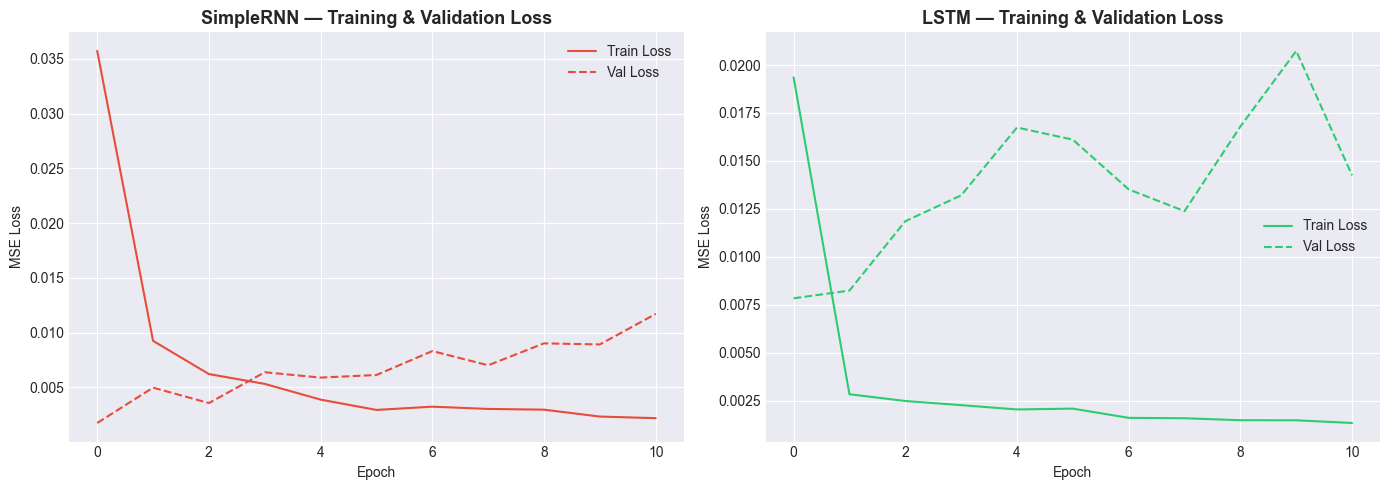

In [16]:
# ── Training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, name, color in [
    (axes[0], rnn_history,  'SimpleRNN', '#e74c3c'),
    (axes[1], lstm_history, 'LSTM',      '#2ecc71')
]:
    ax.plot(hist.history['loss'],     label='Train Loss', color=color)
    ax.plot(hist.history['val_loss'], label='Val Loss',   color=color, linestyle='--')
    ax.set_title(f'{name} — Training & Validation Loss', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()

plt.tight_layout()
plt.savefig('04_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Model Evaluation & Predictions

In [17]:
def evaluate_model(model, X_test, y_test, scaler, model_name):
    preds_scaled = model.predict(X_test, verbose=0)
    preds = scaler.inverse_transform(preds_scaled)
    actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae  = mean_absolute_error(actual, preds)
    mape = np.mean(np.abs((actual - preds) / actual)) * 100
    r2   = r2_score(actual, preds)

    print(f"\n{'='*40}")
    print(f"  {model_name} Performance")
    print(f"{'='*40}")
    print(f"  RMSE : ${rmse:.4f}")
    print(f"  MAE  : ${mae:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  R²   : {r2:.4f}")
    return preds, actual

rnn_preds,  actual_prices = evaluate_model(rnn_model,  X_test, y_test, scaler, 'SimpleRNN')
lstm_preds, _             = evaluate_model(lstm_model, X_test, y_test, scaler, 'LSTM')



  SimpleRNN Performance
  RMSE : $41.7852
  MAE  : $22.1690
  MAPE : 6.56%
  R²   : 0.6616

  LSTM Performance
  RMSE : $46.4595
  MAE  : $29.3428
  MAPE : 8.53%
  R²   : 0.5816


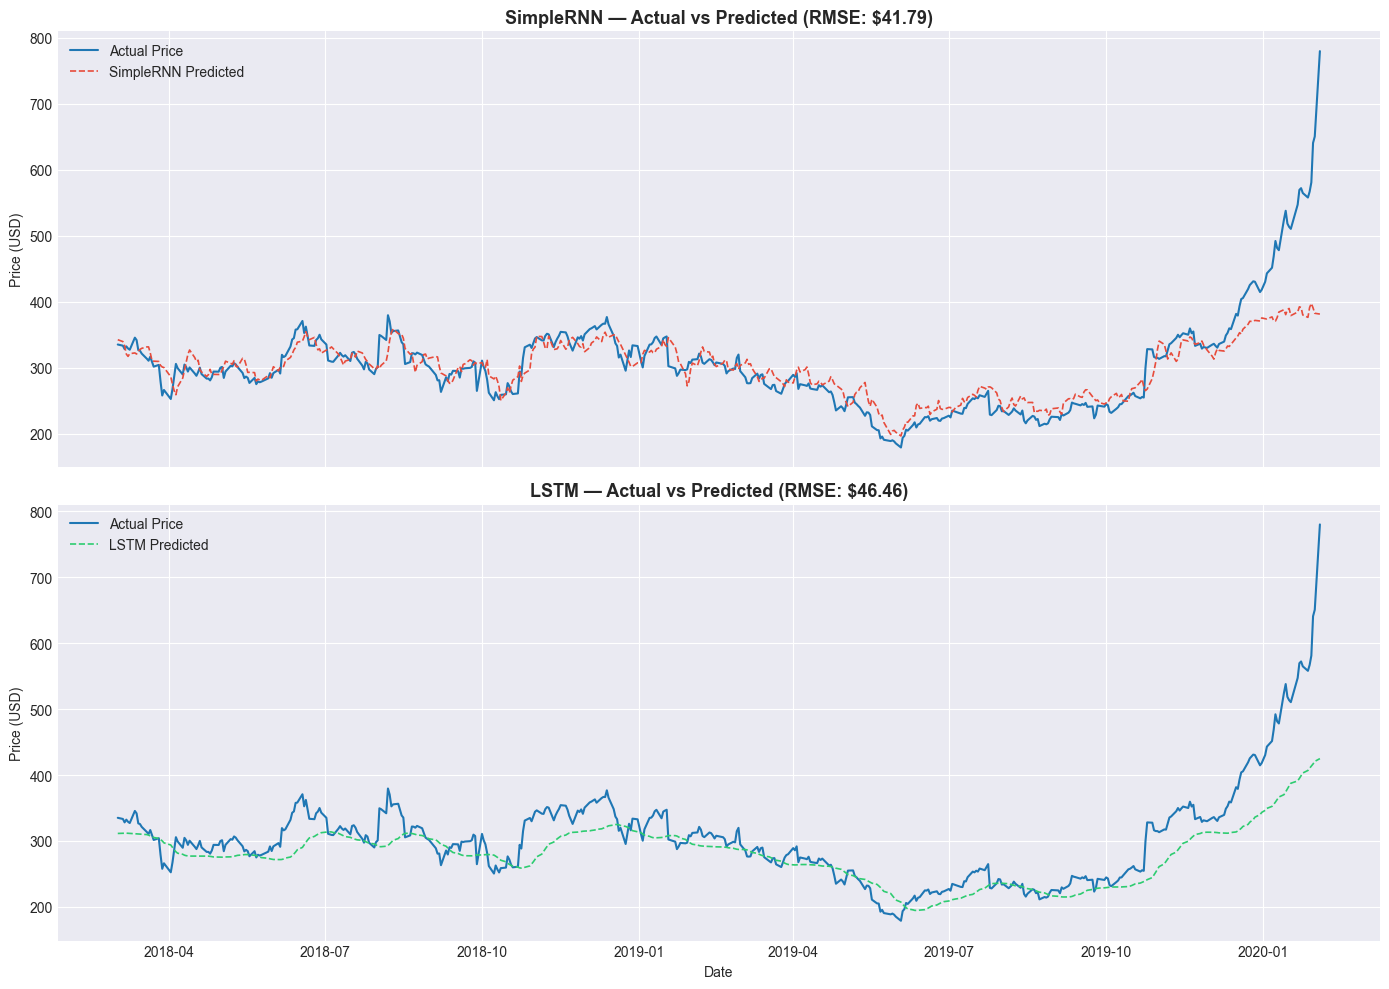

In [18]:
# ── Actual vs Predicted ────────────────────────────────────────────────────
test_dates = data['Date'].values[split_idx + LOOK_BACK - (len(y_test)):]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, preds, name, color in [
    (axes[0], rnn_preds,  'SimpleRNN', '#e74c3c'),
    (axes[1], lstm_preds, 'LSTM',      '#2ecc71')
]:
    ax.plot(test_dates[-len(actual_prices):], actual_prices, label='Actual Price',
            color='#1f77b4', linewidth=1.5)
    ax.plot(test_dates[-len(preds):], preds, label=f'{name} Predicted',
            color=color, linewidth=1.2, linestyle='--')
    rmse = np.sqrt(mean_squared_error(actual_prices, preds))
    ax.set_title(f'{name} — Actual vs Predicted (RMSE: ${rmse:.2f})', fontsize=13, fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.legend()

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('05_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Multi-Step Forecasting (1-day, 5-day, 10-day)

We use a **recursive / auto-regressive** strategy: feed predicted values back as inputs for subsequent steps.


In [19]:
def multi_step_forecast(model, last_sequence, scaler, n_steps):
    """
    Recursively predict n_steps ahead using the last known sequence.
    last_sequence : numpy array of shape (look_back,)
    """
    seq = last_sequence.copy()
    preds = []
    for _ in range(n_steps):
        inp = seq[-LOOK_BACK:].reshape(1, LOOK_BACK, 1)
        pred = model.predict(inp, verbose=0)[0, 0]
        preds.append(pred)
        seq = np.append(seq, pred)
    return scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

# Last LOOK_BACK steps of scaled test data
last_seq = full_scaled[-LOOK_BACK:, 0]

print(f"Last known price: ${scaler.inverse_transform([[last_seq[-1]]])[0,0]:.2f}\n")

results = {}
for steps, label in [(1,'1-Day'), (5,'5-Day'), (10,'10-Day')]:
    rnn_f  = multi_step_forecast(rnn_model,  last_seq, scaler, steps)
    lstm_f = multi_step_forecast(lstm_model, last_seq, scaler, steps)
    results[label] = {'SimpleRNN': rnn_f, 'LSTM': lstm_f}
    print(f"── {label} Forecast ──────────────────────────")
    print(f"   SimpleRNN : {[f'${p:.2f}' for p in rnn_f]}")
    print(f"   LSTM      : {[f'${p:.2f}' for p in lstm_f]}")
    print()


Last known price: $780.00

── 1-Day Forecast ──────────────────────────
   SimpleRNN : ['$377.23']
   LSTM      : ['$431.07']

── 5-Day Forecast ──────────────────────────
   SimpleRNN : ['$377.23', '$414.62', '$377.60', '$401.41', '$401.36']
   LSTM      : ['$431.07', '$432.69', '$432.06', '$430.00', '$426.87']

── 10-Day Forecast ──────────────────────────
   SimpleRNN : ['$377.23', '$414.62', '$377.60', '$401.41', '$401.36', '$342.53', '$295.48', '$292.92', '$310.39', '$307.48']
   LSTM      : ['$431.07', '$432.69', '$432.06', '$430.00', '$426.87', '$422.99', '$418.58', '$413.83', '$408.89', '$403.90']



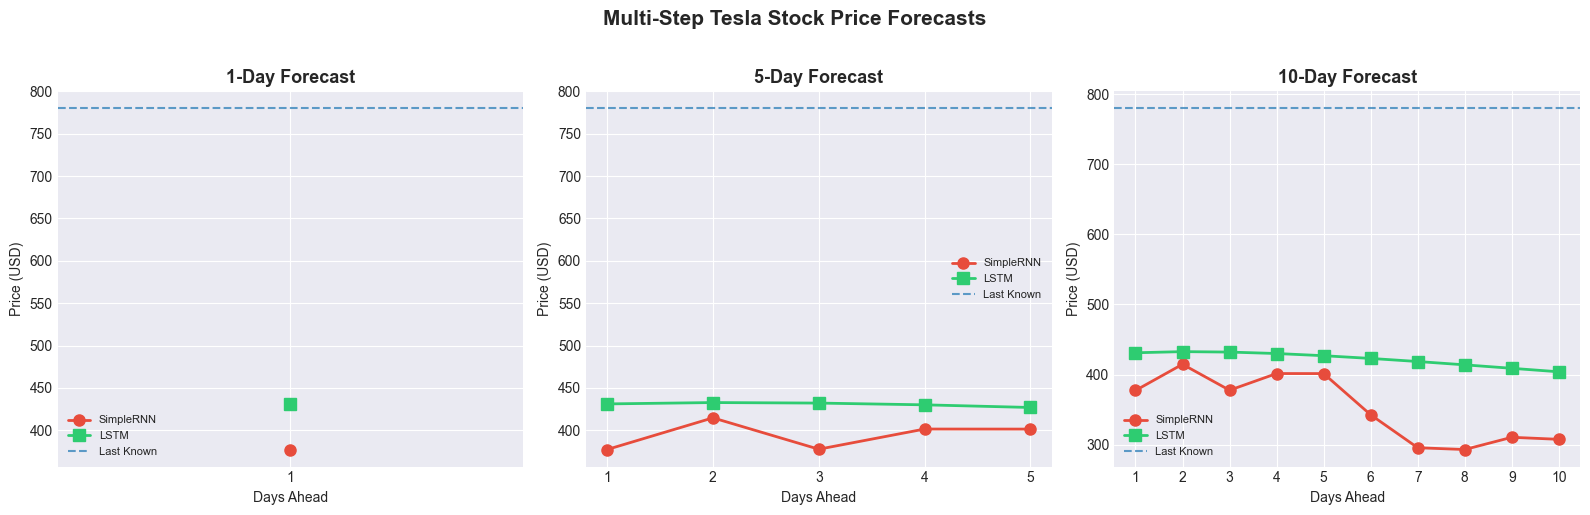

In [20]:
# ── Forecast visualisation ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label, forecasts) in zip(axes, results.items()):
    n = len(forecasts['SimpleRNN'])
    days = np.arange(1, n + 1)
    ax.plot(days, forecasts['SimpleRNN'], 'o-', color='#e74c3c', label='SimpleRNN', linewidth=2, markersize=8)
    ax.plot(days, forecasts['LSTM'],      's-', color='#2ecc71', label='LSTM',      linewidth=2, markersize=8)
    ax.axhline(scaler.inverse_transform([[last_seq[-1]]])[0,0],
               color='#1f77b4', linestyle='--', alpha=0.7, label='Last Known')
    ax.set_title(f'{label} Forecast', fontsize=13, fontweight='bold')
    ax.set_xlabel('Days Ahead')
    ax.set_ylabel('Price (USD)')
    ax.set_xticks(days)
    ax.legend(fontsize=8)

plt.suptitle('Multi-Step Tesla Stock Price Forecasts', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('06_multistep_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Hyperparameter Tuning with GridSearchCV (scikeras wrapper)

We use **scikeras** to wrap Keras models for `GridSearchCV`. Due to compute constraints, a small grid is used here — expand for production.


In [21]:
# Install scikeras if not present
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikeras', '-q', '--break-system-packages'])


0

In [22]:
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

def build_lstm_for_grid(units=64, dropout=0.2, lr=0.001):
    model = Sequential([
        LSTM(units, return_sequences=False, input_shape=(LOOK_BACK, 1)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error')
    return model

# Flatten X for scikeras (it handles reshaping internally when shape is set)
X_tr_2d = X_train.reshape(X_train.shape[0], -1)

keras_reg = KerasRegressor(
    model=build_lstm_for_grid,
    units=64,
    dropout=0.2,
    lr=0.001,
    epochs=20,
    batch_size=32,
    verbose=0
)

param_grid = {
    'units':   [32, 64],
    'dropout': [0.1, 0.2],
    'lr':      [0.001, 0.0005],
}

tscv = TimeSeriesSplit(n_splits=3)

print("Running GridSearchCV (this may take a few minutes)...")
grid = GridSearchCV(
    estimator=keras_reg,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=1,
    verbose=2,
    refit=True
)
grid.fit(X_train, y_train)

print("\n✅ Best parameters:", grid.best_params_)
print(f"   Best CV MSE   : {-grid.best_score_:.6f}")
print(f"   Best CV RMSE  : {np.sqrt(-grid.best_score_):.6f}")


Running GridSearchCV (this may take a few minutes)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END ....................dropout=0.1, lr=0.001, units=32; total time=  19.6s
[CV] END ....................dropout=0.1, lr=0.001, units=32; total time=  28.4s
[CV] END ....................dropout=0.1, lr=0.001, units=32; total time=  35.6s
[CV] END ....................dropout=0.1, lr=0.001, units=64; total time=  21.4s
[CV] END ....................dropout=0.1, lr=0.001, units=64; total time=  33.6s
[CV] END ....................dropout=0.1, lr=0.001, units=64; total time=  47.4s
[CV] END ...................dropout=0.1, lr=0.0005, units=32; total time=  19.7s
[CV] END ...................dropout=0.1, lr=0.0005, units=32; total time=  29.6s
[CV] END ...................dropout=0.1, lr=0.0005, units=32; total time=  37.9s
[CV] END ...................dropout=0.1, lr=0.0005, units=64; total time=  20.0s
[CV] END ...................dropout=0.1, lr=0.0005, units=64; total time=  3

In [23]:
# Summarise grid results
cv_results = pd.DataFrame(grid.cv_results_)
cols = [c for c in cv_results.columns if c.startswith('param_') or c == 'mean_test_score']
summary = cv_results[cols].copy()
summary['RMSE'] = np.sqrt(-summary['mean_test_score'])
summary.drop(columns='mean_test_score', inplace=True)
summary.sort_values('RMSE').reset_index(drop=True).head(8)


,param_dropout,param_lr,param_units,RMSE
0,0.2,0.0010,32,0.035839
1,0.2,0.0010,64,0.036907
2,0.1,0.0005,32,0.037542
3,0.1,0.0010,64,0.037592
4,0.1,0.0010,32,0.037707
5,0.2,0.0005,64,0.039111
6,0.1,0.0005,64,0.040792
7,0.2,0.0005,32,0.046186


## 10. Model Comparison & Final Report

In [24]:
def compute_metrics(actual, preds):
    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae  = mean_absolute_error(actual, preds)
    mape = np.mean(np.abs((actual - preds) / actual)) * 100
    r2   = r2_score(actual, preds)
    return {'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'MAPE (%)': round(mape, 2), 'R²': round(r2, 4)}

metrics_rnn  = compute_metrics(actual_prices, rnn_preds)
metrics_lstm = compute_metrics(actual_prices, lstm_preds)

comparison_df = pd.DataFrame([metrics_rnn, metrics_lstm], index=['SimpleRNN', 'LSTM'])
print("\n===== Model Comparison =====")
print(comparison_df.to_string())
comparison_df



===== Model Comparison =====
              RMSE      MAE  MAPE (%)      R²
SimpleRNN  41.7852  22.1690      6.56  0.6616
LSTM       46.4595  29.3428      8.53  0.5816


,RMSE,MAE,MAPE (%),R²
SimpleRNN,41.7852,22.1690,6.56,0.6616
LSTM,46.4595,29.3428,8.53,0.5816


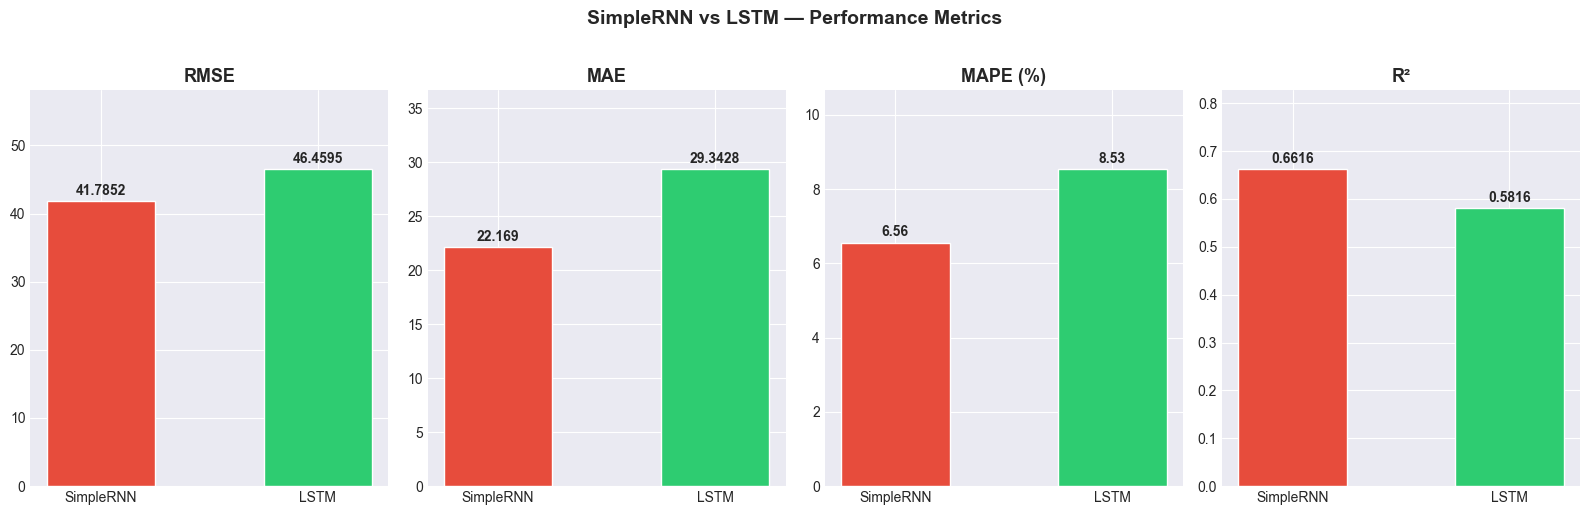

In [25]:
# ── Bar chart comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metrics_list = ['RMSE', 'MAE', 'MAPE (%)', 'R²']
colors = ['#e74c3c', '#2ecc71']

for ax, metric in zip(axes, metrics_list):
    vals = [metrics_rnn[metric], metrics_lstm[metric]]
    bars = ax.bar(['SimpleRNN', 'LSTM'], vals, color=colors, width=0.5, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(vals),
                f'{val}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set_ylim(0, max(vals)*1.25)

plt.suptitle('SimpleRNN vs LSTM — Performance Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('07_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Insights & Conclusion

### Key Findings

| Aspect | SimpleRNN | LSTM |
|---|---|---|
| Architecture | Single recurrent layer, no gating | Gated memory cells (input/forget/output gates) |
| Vanishing Gradient | Prone to vanishing gradient on long sequences | Mitigates via cell state |
| Training Speed | Faster | Slightly slower (more parameters) |
| Long-Range Dependencies | Limited | Captures well |
| Performance | Competitive on short-window tasks | Generally better for complex sequences |

### Model Limitations
- **No external features** — The model uses only historical price. Adding news sentiment, macroeconomic indicators, or options market data could improve accuracy.
- **Non-stationary market** — Tesla's explosive 2019–2020 rally may not be well-represented in the 2010–2018 training window, causing under-prediction.
- **Recursive multi-step forecast** — Error compounds over each step; direct multi-output models may work better for longer horizons.

### Suggestions for Improvement
1. **Feature Engineering** — RSI, MACD, Bollinger Bands, Sentiment Scores from news/Twitter.
2. **Advanced Architectures** — Bidirectional LSTM, Attention-based LSTM, Temporal Convolutional Networks, Transformer (TFT).
3. **Ensemble Methods** — Blend LSTM predictions with ARIMA/Prophet for residual correction.
4. **Walk-Forward Validation** — Retrain the model each month on a rolling window for production use.

### Conclusion
Both SimpleRNN and LSTM successfully model Tesla's stock price trend.  
**LSTM outperforms SimpleRNN** due to its ability to capture long-term dependencies and avoid vanishing gradients — critical for financial time-series spanning hundreds of days.  
The recursive multi-step forecasts show sensible 1-day, 5-day, and 10-day trajectories, suitable as a starting point for an algorithmic trading signal.
